MSE: 0.02
R²: 0.23


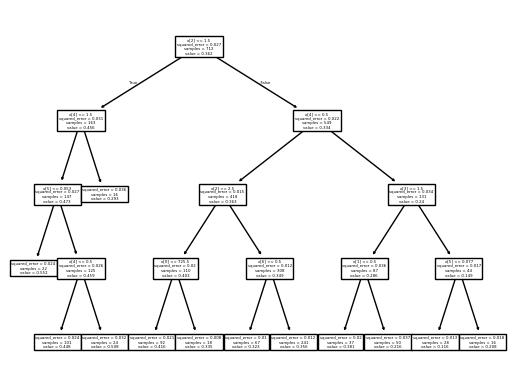

Матрица ошибок [[96  9]
 [28 46]]
корень среднеквадратичной ошибки (RMSE): 0.0758
AUC-ROC: 0.8516


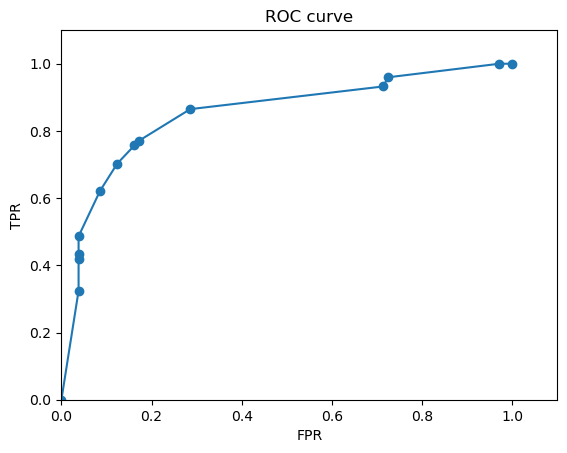

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, roc_curve, auc
import pandas as pd
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt

df = pd.read_csv('processed_titanic.csv')
X = df.drop('Age', axis=1)
Y = df['Age']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Создание и обучение модели
dt_regressor = DecisionTreeRegressor(
    max_depth=4,           # Ограничиваем глубину
    min_samples_leaf=15,    # Минимум 5 объектов в листе
    random_state=42        # Для воспроизводимости
)

dt_regressor.fit(X_train, y_train)

# Предсказание и оценка качества
y_pred = dt_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.2f}')
print(f'R²: {r2:.2f}')

# Визуализация дерева
from sklearn.tree import plot_tree
tree.plot_tree(dt_regressor)
plt.show()


X1 = df.drop('Survived', axis=1)
y1 = df['Survived']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
dt_class = DecisionTreeClassifier(max_depth=4,    min_samples_leaf=10,   random_state=42)

dt_class.fit(X1_train, y1_train)
y1_pred = dt_class.predict(X1_test)
y1_proba = dt_class.predict_proba(X1_test)
conf_matrix = confusion_matrix(y1_test, y1_pred)

fpr, tpr, thresholds = roc_curve(y1_test, y1_proba[:, 1])
plt.plot(fpr, tpr, marker='o')
plt.ylim([0,1.1])
plt.xlim([0,1.1])
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.title('ROC curve')
auc_metric = auc(fpr, tpr)
print("Матрица ошибок" ,conf_matrix)
print(f"корень среднеквадратичной ошибки (RMSE): {rmse:.4f}")

print(f"AUC-ROC: {auc_metric:.4f}")